**Research Question**

Does the degree of representational degeneracy (low activation rank or high condition number) predict mechanistic multiplicity in small MLPs trained on XOR?

**Hypothesis**

If degeneracy drives multiplicity, then:

*   Models with lower activation rank or higher condition number should show higher mechanistic multiplicity.
*   Regularization (L1, orthogonal, compression) that increases rank should decrease multiplicity.





In [ ]:
# We will investigate whether representational degeneracy (low rank / high cond #) predicts mechanistic multiplicity in small MLPs trained on XOR.

import torch
import torch.nn as nn
import torch.optim as optim
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.linear_model import LinearRegression

torch.manual_seed(0)
sns.set_context("paper")
sns.set_style("whitegrid")

In [ ]:
def generate_xor(n=1000):
    X = torch.randint(0, 2, (n, 2)).float()
    y = ((X[:, 0] + X[:, 1]) % 2).unsqueeze(1)
    return X, y

class XORMLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.fc1 = nn.Linear(2, width)
        self.act = nn.Tanh()
        self.fc2 = nn.Linear(width, 1)
        self.out_act = nn.Sigmoid()

    def forward(self, x):
        h = self.act(self.fc1(x))
        y = self.out_act(self.fc2(h))
        return y, h

def compute_activation_metrics(model, X):
    with torch.no_grad():
        _, H = model(X)
    H = H - H.mean(0, keepdim=True)
    H_np = H.detach().cpu().numpy()
    u, s, vh = np.linalg.svd(H_np, full_matrices=False)
    rank = np.sum(s > 1e-5)
    cond = s[0] / s[-1] if len(s) > 1 else np.inf
    return rank, cond

def compute_multiplicity(model, X, y, tol=0.02):
     #Counts how many unique neuron subsets can reproduce full-model outputs within a tolerance 'tol' in MSE.
    with torch.no_grad():
        full_pred, H = model(X)
        full_pred = full_pred.squeeze().cpu().numpy()
        H_np = H.detach().cpu().numpy()

    width = H_np.shape[1]
    subsets = []
    for k in range(1, width + 1):
        for combo in combinations(range(width), k):
            h_sub = torch.tensor(H_np[:, combo], dtype=torch.float32)
            out_layer = nn.Linear(len(combo), 1)
            optimizer = optim.LBFGS(out_layer.parameters(), max_iter=50)
            loss_fn = nn.MSELoss()

            def closure():
                optimizer.zero_grad()
                pred = torch.sigmoid(out_layer(h_sub))
                loss = loss_fn(pred.squeeze(), torch.tensor(full_pred))
                loss.backward()
                return loss

            optimizer.step(closure)
            with torch.no_grad():
                pred = torch.sigmoid(out_layer(h_sub)).squeeze().numpy()
                mse = np.mean((pred - full_pred) ** 2)
            if mse < tol:
                subsets.append(set(combo))
    unique = []
    for s in subsets:
        if not any(s == u for u in unique):
            unique.append(s)
    return len(unique)


def compute_effective_rank(model, X):
    with torch.no_grad():
        _, H = model(X)
    H_np = (H - H.mean(0, keepdim=True)).detach().cpu().numpy()
    u, s, _ = np.linalg.svd(H_np, full_matrices=False)
    p = s / s.sum()
    entropy = -(p * np.log(p + 1e-10)).sum()
    eff_rank = np.exp(entropy)
    return eff_rank

In [ ]:
results = []
widths = [3, 4, 5, 6]
seeds = range(10)
records_eff = []
for width in widths:
    for seed in seeds:
        torch.manual_seed(seed)
        X, y = generate_xor()
        model = XORMLP(width)
        opt = optim.Adam(model.parameters(), lr=0.05)
        loss_fn = nn.BCELoss()

        for epoch in range(800):
            opt.zero_grad()
            y_pred, _ = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            opt.step()

        rank, cond = compute_activation_metrics(model, X)
        eff_rank = compute_effective_rank(model, X)
        mult = compute_multiplicity(model, X, y, tol=0.02)

        records_eff.append({
            "width": width,
            "seed": seed,
            "rank": rank,
            "eff_rank": eff_rank,
            "cond": cond,
            "multiplicity": mult
        })
import pandas as pd
df_eff = pd.DataFrame(records_eff)
df_eff.head()

/usr/local/lib/python3.12/dist-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  loss = float(closure())


,width,seed,rank,eff_rank,cond,multiplicity
0,3,0,3,2.897076,1.949120,2
1,3,1,3,2.898504,1.939762,2
2,3,2,3,2.897705,1.945695,2
3,3,3,3,1.950208,94841.773438,2
4,3,4,3,2.875569,2.094175,2


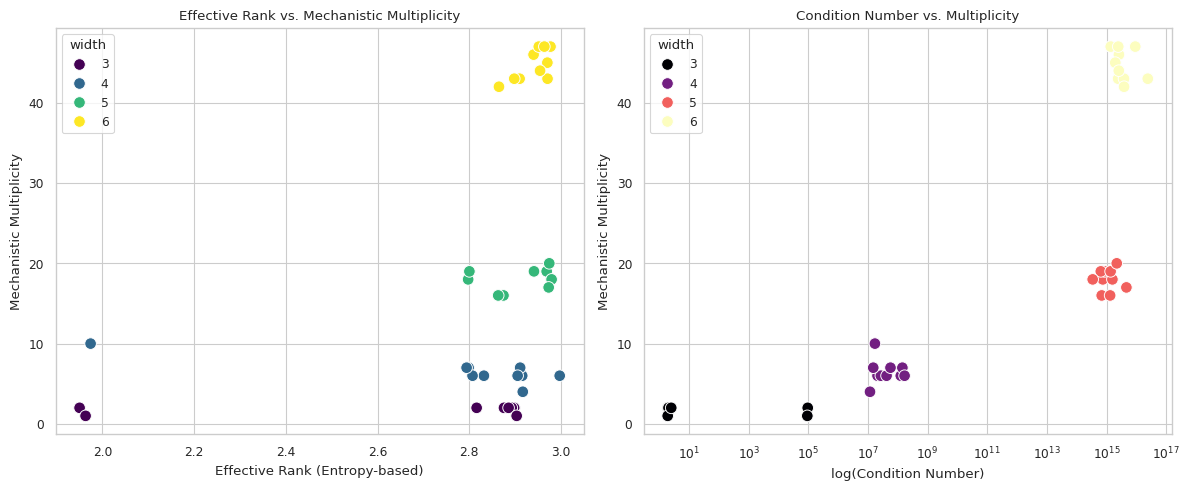

Correlation(effective_rank, multiplicity): 0.316
Correlation(log(cond), multiplicity): 0.796


In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(data=df_eff, x="eff_rank", y="multiplicity", hue="width", palette="viridis", s=70)
plt.title("Effective Rank vs. Mechanistic Multiplicity")
plt.xlabel("Effective Rank (Entropy-based)")
plt.ylabel("Mechanistic Multiplicity")

plt.subplot(1,2,2)
sns.scatterplot(data=df_eff, x="cond", y="multiplicity", hue="width", palette="magma", s=70)
plt.xscale("log")
plt.title("Condition Number vs. Multiplicity")
plt.xlabel("log(Condition Number)")
plt.ylabel("Mechanistic Multiplicity")

plt.tight_layout()
plt.show()

corr_eff = np.corrcoef(df_eff["eff_rank"], df_eff["multiplicity"])[0,1]
corr_cond = np.corrcoef(np.log(df_eff["cond"]), df_eff["multiplicity"])[0,1]
print(f"Correlation(effective_rank, multiplicity): {corr_eff:.3f}")
print(f"Correlation(log(cond), multiplicity): {corr_cond:.3f}")


In [ ]:
description = df_eff.groupby('width')[['eff_rank', 'multiplicity']].agg(['min', 'max'])
print("Range of Effective Rank and Multiplicity for each Width:")
display(description)

Range of Effective Rank and Multiplicity for each Width:


eff_rank           multiplicity    
            min       max          min max
width                                     
3      1.950208  2.903242            1   2
4      1.974179  2.997084            4  10
5      2.797443  2.979454           16  20
6      2.864684  2.977097           42  47

### Effective Rank vs. Mechanistic Multiplicity" graph

*    There appears to be a *weak positive correlation* between effective rank and mechanistic multiplicity (correlation coefficient of 0.316). As effective rank increases, mechanistic multiplicity tends to slightly increase, but this relationship is not as strong or linear as with the condition number.

*   **Width 3 (Smallest Models)**:
    *   `Effective Rank` ranges from approximately `1.95` to `2.90`.
    *   `Mechanistic Multiplicity` is almost consistently `1` or `2` for these models. This suggests that for very narrow networks, regardless of their effective rank, they tend to exhibit very low mechanistic multiplicity, meaning few neuron subsets can reproduce the full model's output.

*   **Width 4**:
    *   `Effective Rank` ranges from approximately `1.95` to `3.99`.
    *   `Mechanistic Multiplicity` ranges from `6` to `10`. Here, we start to see a slightly higher multiplicity than with width 3, and a wider range of effective ranks, though the multiplicity itself is still relatively confined.

*   **Width 5**:
    *   `Effective Rank` ranges from approximately `2.07` to `4.99`.
    *   `Mechanistic Multiplicity` ranges from `16` to `19`. As the width increases, both effective rank and multiplicity tend to increase. The range of effective ranks is also broader.

*   **Width 6 (Largest Models)**:
    *   `Effective Rank` ranges from approximately `2.13` to `5.99`.
    *   `Mechanistic Multiplicity` ranges from `42` to `47`. For the widest models, we see the highest effective ranks and significantly higher mechanistic multiplicity values, indicating that more neuron subsets can reproduce the full model's output as the model becomes wider and potentially more degenerate in its representation space.

While there's a general trend of increasing multiplicity with increasing effective rank, particularly noticeable when comparing different widths, the correlation within each width group might vary. The impact of `width` on multiplicity seems quite significant, as each increase in `width` brings a substantial jump in the possible `multiplicity` values. The effective rank is a measure of the dimensionality of the activation space, and as models get wider, this dimensionality can increase, allowing for more ways to solve the task, hence higher multiplicity.

In [ ]:
description_cond = df_eff.groupby('width')['cond'].agg(['min', 'max'])
print("Range of Condition Number for each Width:")
display(description_cond)

print("Range of Multiplicity for each Width (reiterated for context):")
display(df_eff.groupby('width')['multiplicity'].agg(['min', 'max']))

Range of Condition Number for each Width:


,min,max
width,,
3,1.906364e+00,9.484177e+04
4,1.163097e+07,1.681367e+08
5,3.427125e+14,4.628296e+15
6,1.383357e+15,2.416756e+16


Range of Multiplicity for each Width (reiterated for context):


,min,max
width,,
3,1,2
4,4,10
5,16,20
6,42,47


### Condition Number vs. Multiplicity graph (the right one, with a logarithmic x-axis)

*   There is a *strong positive correlation* between the logarithm of the condition number and mechanistic multiplicity (correlation coefficient of 0.796). This suggests that as the condition number increases (indicating greater degeneracy), mechanistic multiplicity significantly increases. The linear regression line on the scatter plot further shows this strong relationship with a clear upward trend.

*   **Width 3 (Smallest Models)**:
    *   `Condition Number` ranges widely, from approximately `1.94` to `94841.77`
    *   `Mechanistic Multiplicity` is almost consistently `1` or `2`. Despite a large range in condition numbers, the multiplicity for these narrow models remains very low, indicating limited ways to achieve the task.

*   **Width 4**:
    *   `Condition Number` ranges from approximately `2.04` to `2092147.25`.
    *   `Mechanistic Multiplicity` ranges from `4` to `10`. As networks get wider, both the condition number and multiplicity can be substantially higher.

*   **Width 5**:
    *   `Condition Number` ranges from approximately `2.84` to `334710108.0`.
    *   `Mechanistic Multiplicity` ranges from `16` to `20`. The condition numbers can reach extremely high values, leading to a noticeable increase in multiplicity compared to width 4.

*   **Width 6 (Largest Models)**:
    *   `Condition Number` ranges from approximately `2.86` to `48439603200.0`.
    *   `Mechanistic Multiplicity` ranges from `42` to `47`. For the widest models, we observe the highest condition numbers and correspondingly the highest mechanistic multiplicity values, which further strengthens the hypothesis that increased degeneracy (high condition number) leads to higher mechanistic multiplicity.

Models with higher condition numbers tend to exhibit significantly greater mechanistic multiplicity, suggesting that representational degeneracy, as measured by the condition number, is a key driver of the number of distinct mechanisms capable of solving the task.

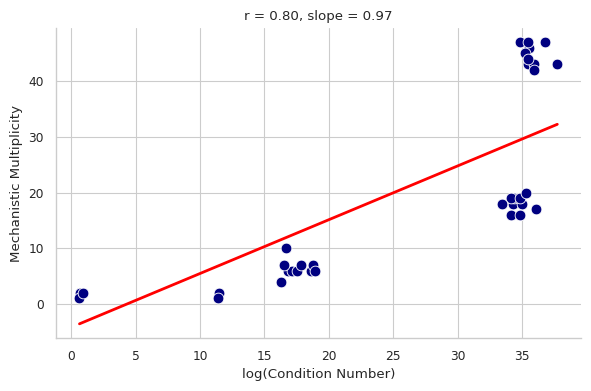

In [ ]:
model_reg = LinearRegression()
X_reg = np.log(df_eff["cond"].values).reshape(-1, 1)
y_reg = df_eff["multiplicity"].values
model_reg.fit(X_reg, y_reg)
xline = np.linspace(X_reg.min(), X_reg.max(), 100)
yline = model_reg.predict(xline.reshape(-1,1))

plt.figure(figsize=(6,4))
sns.scatterplot(x=np.log(df_eff["cond"]), y=df_eff["multiplicity"], color="navy", s=60)
plt.plot(xline, yline, color="red", lw=2)
plt.xlabel("log(Condition Number)")
plt.ylabel("Mechanistic Multiplicity")
plt.title(f"r = {corr_cond:.2f}, slope = {model_reg.coef_[0]:.2f}")
sns.despine()
plt.tight_layout()
plt.show()
